In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

%matplotlib inline

In [3]:
RAW_DATA_PATH = './data/raw'
train_data = pd.read_csv(f'{RAW_DATA_PATH}/train.csv')
test_data = pd.read_csv(f'{RAW_DATA_PATH}/test.csv')

In [4]:
raw_data = pd.concat([train_data, test_data])
print(raw_data)

                                         original_text     source  pornografi  \
0    [QUOTE=jessepinkman16;5a50ac34d89b093f368b456e...     kaskus           0   
1    @verosvante kita2 aja nitizen yang pada kepo,t...  instagram           0   
2    "#SidangAhok smg sipenista agama n ateknya mat...    twitter           0   
3    @bolususulembang.jkt barusan baca undang2 ini....  instagram           0   
4    bikin anak mulu lu nof \nkaga mikir apa kasian...     kaskus           0   
..                                                 ...        ...         ...   
773  RT @KapalKertasFFI: Meski hanya Show Of Force,...    twitter           0   
774  Da ky fpi u be, haha RT @jeffrey_stwn: hajar C...    twitter           0   
775  Manahan pantat isi nya lemak semua. Gua suuzon...  instagram           1   
776  @uzman910 kw tebak sndri la,... kok cmna..biar...  instagram           0   
777  Emang negro ga boleh ya bre pake sweater atau ...     kaskus           0   

     sara  radikalisme  pen

In [5]:
raw_data.head()

,original_text,source,pornografi,sara,radikalisme,pencemaran_nama_baik
0,[QUOTE=jessepinkman16;5a50ac34d89b093f368b456e...,kaskus,0,0,0,1
1,"@verosvante kita2 aja nitizen yang pada kepo,t...",instagram,0,0,0,0
2,"""#SidangAhok smg sipenista agama n ateknya mat...",twitter,0,1,1,1
3,@bolususulembang.jkt barusan baca undang2 ini....,instagram,0,0,0,0
4,bikin anak mulu lu nof \nkaga mikir apa kasian...,kaskus,0,0,0,0


In [6]:
raw_data.describe()

,pornografi,sara,radikalisme,pencemaran_nama_baik
count,7773.000000,7773.000000,7773.000000,7773.000000
mean,0.224752,0.159269,0.164158,0.311977
std,0.417446,0.365951,0.370443,0.463330
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000


In [7]:
train_data.head()

,original_text,source,pornografi,sara,radikalisme,pencemaran_nama_baik
0,[QUOTE=jessepinkman16;5a50ac34d89b093f368b456e...,kaskus,0,0,0,1
1,"@verosvante kita2 aja nitizen yang pada kepo,t...",instagram,0,0,0,0
2,"""#SidangAhok smg sipenista agama n ateknya mat...",twitter,0,1,1,1
3,@bolususulembang.jkt barusan baca undang2 ini....,instagram,0,0,0,0
4,bikin anak mulu lu nof \nkaga mikir apa kasian...,kaskus,0,0,0,0


In [8]:
train_data.describe()

,pornografi,sara,radikalisme,pencemaran_nama_baik
count,6995.000000,6995.000000,6995.000000,6995.000000
mean,0.225018,0.160686,0.164975,0.311651
std,0.417624,0.367268,0.371185,0.463201
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000


In [9]:
test_data.head()

,original_text,source,pornografi,sara,radikalisme,pencemaran_nama_baik
0,"1.BUKAN CM SPANDUK PROF,VIDEO2 ORASI MEREKA, B...",twitter,0,0,1,0
1,@memeqbeceq gy sange'gatel yh tetek'memekY drn...,twitter,1,0,0,0
2,Pertama kali denger lagunya enk bgt in dan png...,instagram,0,0,0,0
3,"astajim, ini pasti yg kasih penghargaan ke ibu...",kaskus,0,0,0,0
4,beda kalo disini kalo komplain lgs di bully am...,kaskus,0,0,0,0


In [10]:
test_data.describe()

,pornografi,sara,radikalisme,pencemaran_nama_baik
count,778.000000,778.000000,778.000000,778.000000
mean,0.222365,0.146530,0.156812,0.314910
std,0.416103,0.353864,0.363858,0.464779
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000


0      386
1      458
2      140
3      348
4      104
      ... 
773    142
774    124
775    104
776    109
777     85
Name: original_text, Length: 7773, dtype: int64


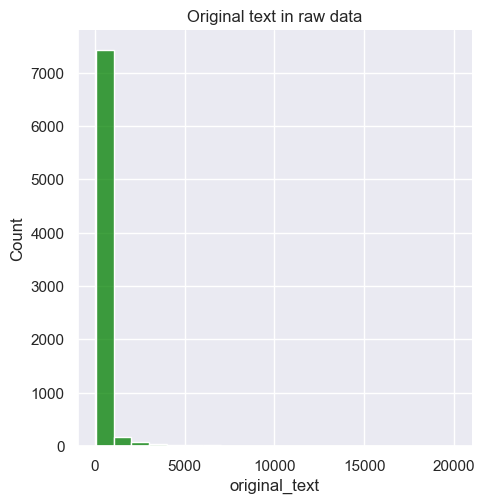

In [11]:
sns.set(color_codes=True)
comment_len = raw_data.original_text.str.len()
sns.displot(comment_len, kde=False, bins=20,color="green").set(title="Original text in raw data")
print(comment_len)

0       386
1       458
2       140
3       348
4       104
       ... 
6990    137
6991    169
6992    130
6993    113
6994    137
Name: original_text, Length: 6995, dtype: int64


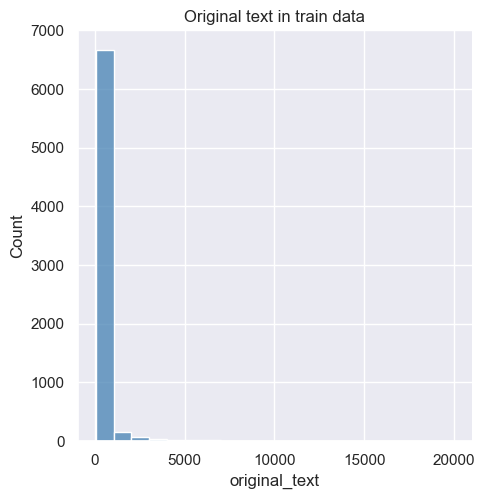

In [12]:
sns.set(color_codes=True)
comment_len = train_data.original_text.str.len()
sns.displot(comment_len, kde=False, bins=20, color="steelblue").set(title="Original text in train data")
print(comment_len)

0      257
1      140
2      164
3      121
4      120
      ... 
773    142
774    124
775    104
776    109
777     85
Name: original_text, Length: 778, dtype: int64


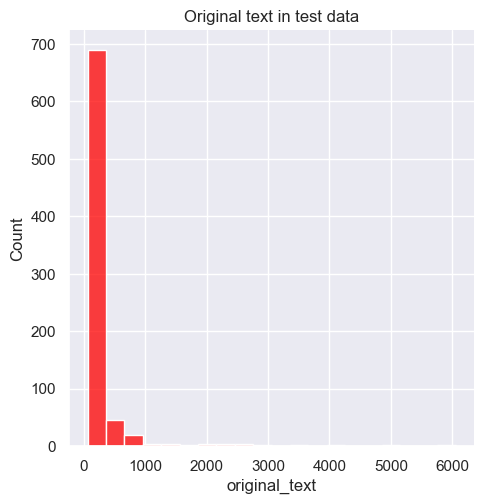

In [13]:
sns.set(color_codes=True)
comment_len = test_data.original_text.str.len()
sns.displot(comment_len, kde=False, bins=20, color="red").set(title="Original text in test data")
print(comment_len)

In [14]:

print('Train data shape: ', train_data.shape)
print('Test data shape: ', test_data.shape)
print('Raw data shape: ', raw_data.shape)

Train data shape:  (6995, 6)
Test data shape:  (778, 6)
Raw data shape:  (7773, 6)


In [15]:

labels = ['pornografi', 'sara', 'radikalisme', 'pencemaran_nama_baik']

In [16]:

def get_label_distribution(data, label):
    return np.sum(data[label])

def get_label_distribution_percent(data, label):
    return np.sum(data[label] / data.shape[0])

In [17]:

for list_column in labels:
    print(raw_data[list_column].value_counts())

pornografi
0    6026
1    1747
Name: count, dtype: int64
sara
0    6535
1    1238
Name: count, dtype: int64
radikalisme
0    6497
1    1276
Name: count, dtype: int64
pencemaran_nama_baik
0    5348
1    2425
Name: count, dtype: int64


<Axes: title={'center': 'Labels Frequency for raw data'}>

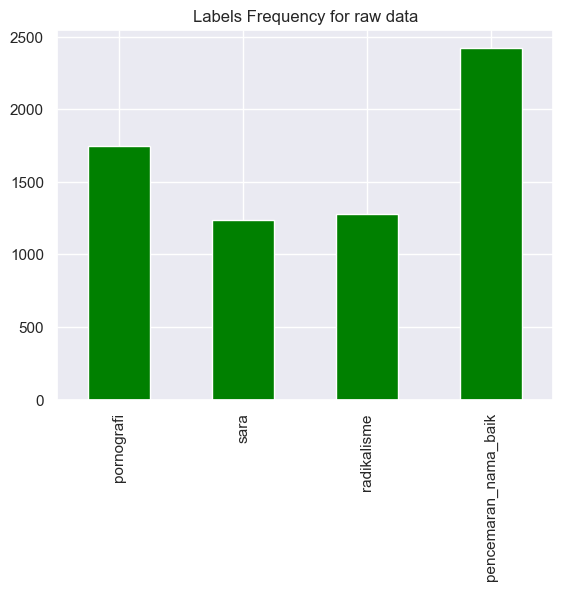

In [18]:

raw_labels = raw_data[labels]
label_count = raw_labels.sum()
label_count.plot(kind='bar', title='Labels Frequency for raw data', color='green')

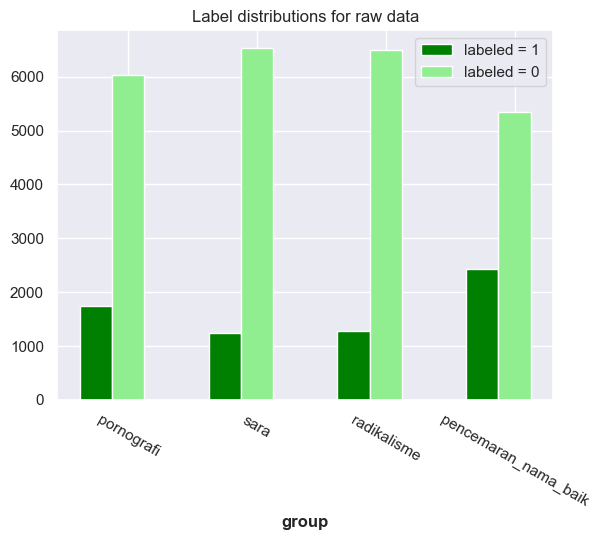

In [19]:
barWidth = 0.25

bars1 = [sum(raw_data['pornografi'] == 1), sum(raw_data['sara'] == 1), sum(raw_data['radikalisme'] == 1),
        sum(raw_data['pencemaran_nama_baik'] == 1)]
bars2 = [sum(raw_data['pornografi'] == 0), sum(raw_data['sara'] == 0), sum(raw_data['radikalisme'] == 0),
        sum(raw_data['pencemaran_nama_baik'] == 0)]

r1 = np.arange(len(bars1))
r2 = [x + barWidth for x in r1]
plt.bar(r1, bars1, color='green', width=barWidth, label='labeled = 1')
plt.bar(r2, bars2, color='lightgreen', width=barWidth, label='labeled = 0')

plt.xlabel('group', fontweight='bold')
plt.xticks([r + barWidth for r in range(len(bars1))], labels, rotation = -30)

plt.title("Label distributions for raw data")
plt.legend()
plt.show()

<Axes: title={'center': 'Labels Frequency for training data'}>

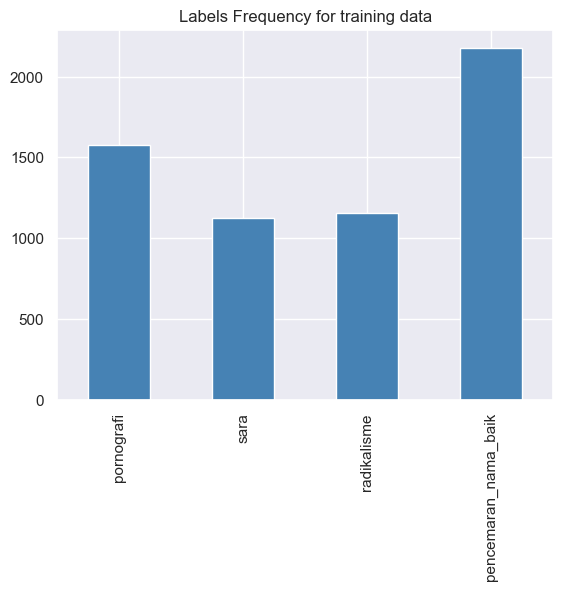

In [20]:
train_labels = train_data[labels]
label_count = train_labels.sum()
label_count.plot(kind='bar', title='Labels Frequency for training data', color='steelblue')


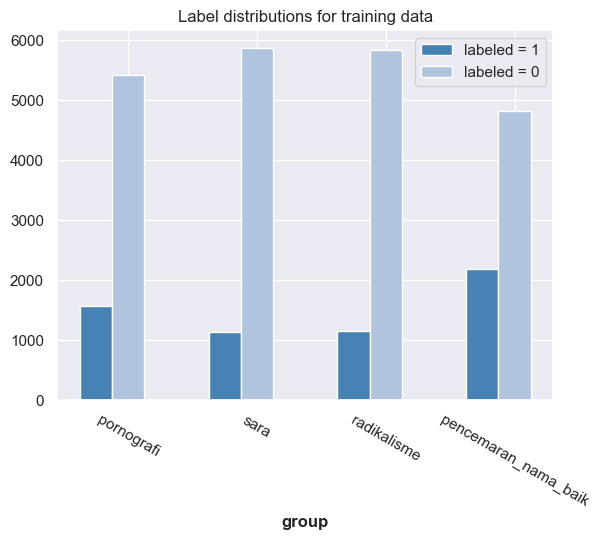

In [21]:
barWidth = 0.25

bars1 = [sum(train_data['pornografi'] == 1), sum(train_data['sara'] == 1), sum(train_data['radikalisme'] == 1),
        sum(train_data['pencemaran_nama_baik'] == 1)]
bars2 = [sum(train_data['pornografi'] == 0), sum(train_data['sara'] == 0), sum(train_data['radikalisme'] == 0),
        sum(train_data['pencemaran_nama_baik'] == 0)]

r1 = np.arange(len(bars1))
r2 = [x + barWidth for x in r1]
plt.bar(r1, bars1, color='steelblue', width=barWidth, label='labeled = 1')
plt.bar(r2, bars2, color='lightsteelblue', width=barWidth, label='labeled = 0')

plt.xlabel('group', fontweight='bold')
plt.xticks([r + barWidth for r in range(len(bars1))], labels, rotation = -30)

plt.title("Label distributions for training data")
plt.legend()
plt.show()

<Axes: title={'center': 'Labels Frequency for training data'}>

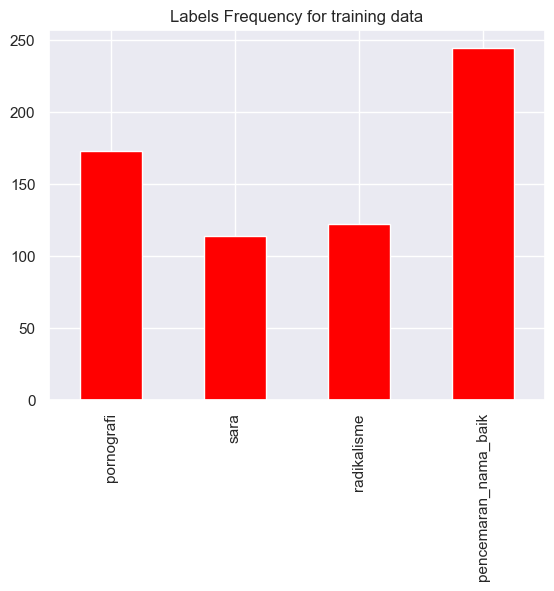

In [22]:
test_labels = test_data[labels]
label_count = test_labels.sum()
label_count.plot(kind='bar', title='Labels Frequency for training data', color='red')


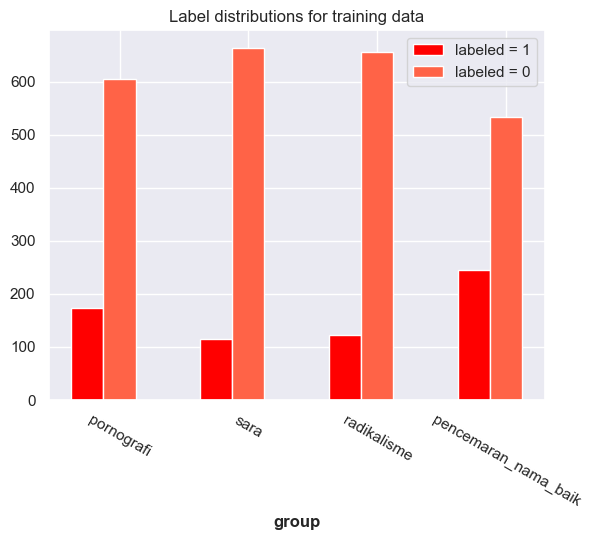

In [23]:
barWidth = 0.25

bars1 = [sum(test_data['pornografi'] == 1), sum(test_data['sara'] == 1), sum(test_data['radikalisme'] == 1),
        sum(test_data['pencemaran_nama_baik'] == 1)]
bars2 = [sum(test_data['pornografi'] == 0), sum(test_data['sara'] == 0), sum(test_data['radikalisme'] == 0),
        sum(test_data['pencemaran_nama_baik'] == 0)]

r1 = np.arange(len(bars1))
r2 = [x + barWidth for x in r1]
plt.bar(r1, bars1, color='red', width=barWidth, label='labeled = 1')
plt.bar(r2, bars2, color='tomato', width=barWidth, label='labeled = 0')

plt.xlabel('group', fontweight='bold')
plt.xticks([r + barWidth for r in range(len(bars1))], labels, rotation = -30)

plt.title("Label distributions for training data")
plt.legend()
plt.show()

<Axes: >

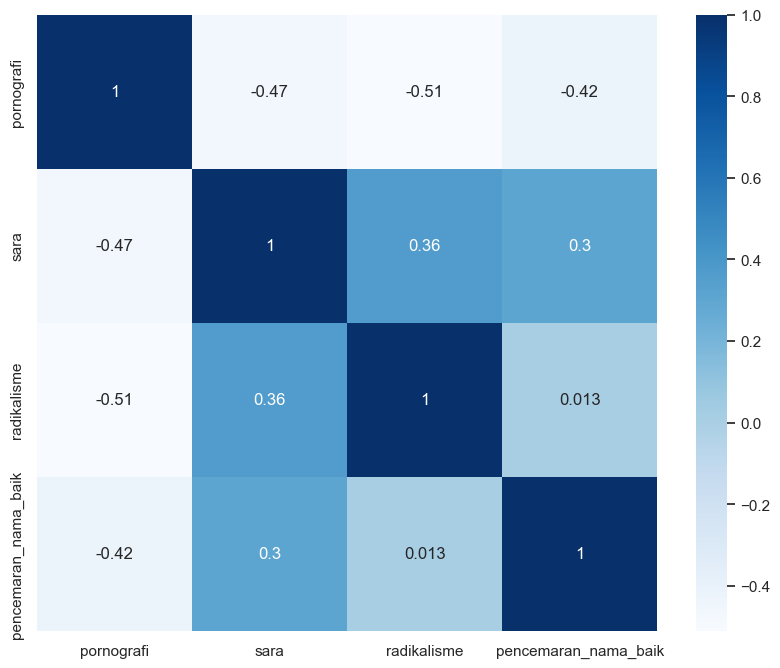

In [24]:
rowsums = train_data.iloc[:, 2:].sum(axis=1)
temp = train_data.iloc[:, 2:]
train_corr = temp[rowsums > 0]
corr = train_corr.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr,
           xticklabels=corr.columns.values,
           yticklabels=corr.columns.values, annot=True, cmap='Blues')